In [2]:
%pip install pygad

Note: you may need to restart the kernel to use updated packages.


Initial guess [-1.7, 1.5], Result: [0.99999588 0.99999174], Value: 1.703332872097716e-11, Success: True, Iterations: 27, Time: 0.0418 sec
Initial guess [3.2, 0.9], Result: [0.99999539 0.99999077], Value: 2.1276950202004517e-11, Success: True, Iterations: 41, Time: 0.0376 sec
Initial guess [1.5, -0.4], Result: [0.99999549 0.99999095], Value: 2.0415729879201015e-11, Success: True, Iterations: 23, Time: 0.0124 sec


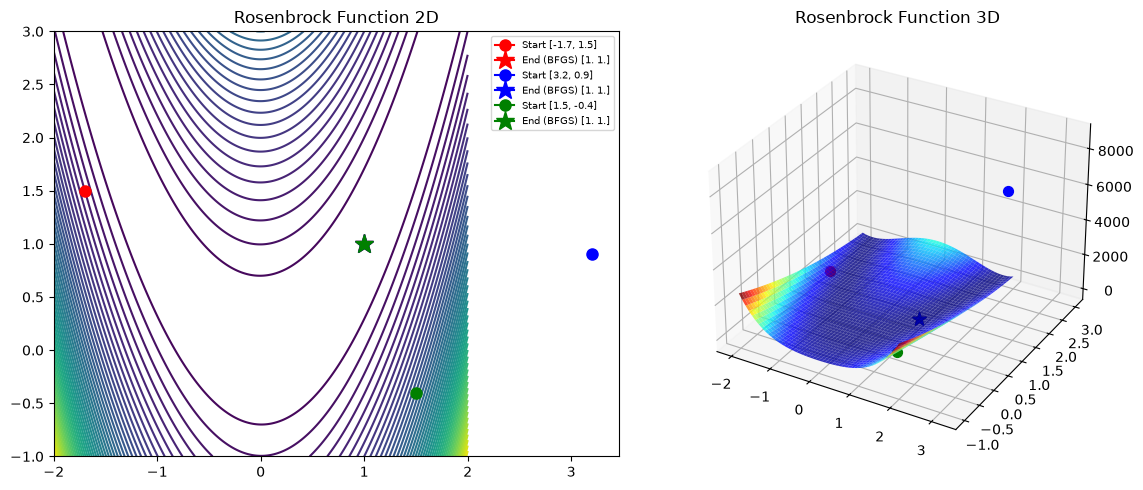

PyGAD initial guess [-1.7, 1.5], Solution: [0.93919053 0.88227582], Value: 0.003701671573928912, iterations: 2000, Time: 1.8219 sec
PyGAD initial guess [3.2, 0.9], Solution: [1.01503483 1.02985504], Value: 0.00024546440463755115, iterations: 2000, Time: 1.5806 sec
PyGAD initial guess [1.5, -0.4], Solution: [0.9781431  0.95684226], Value: 0.00047833775716493493, iterations: 2000, Time: 1.7845 sec


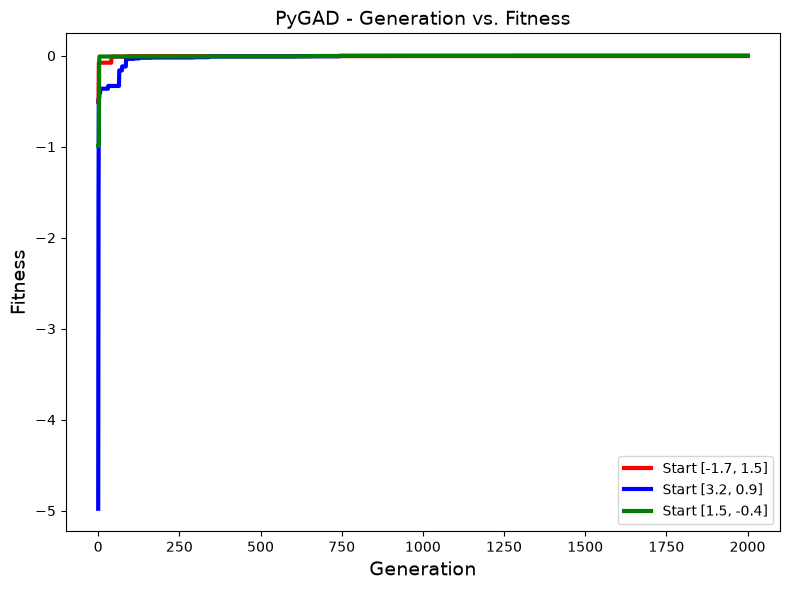

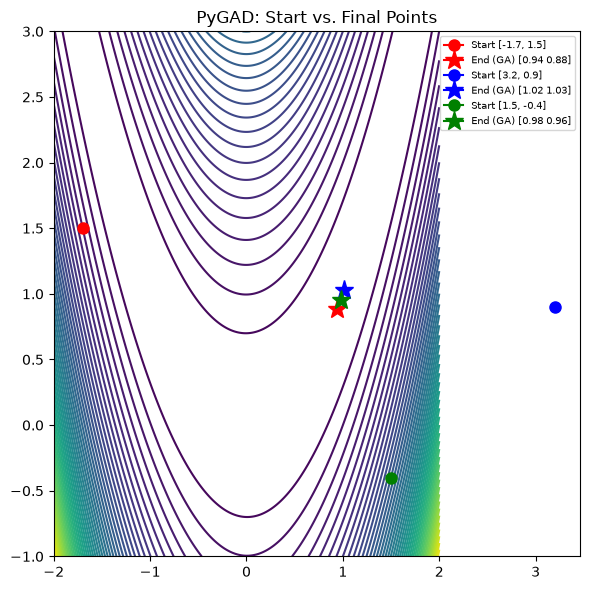

In [11]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")

init_guesses = [[-1.7, 1.5], [3.2, .9], [1.5, -0.4]]
colors = ['red', 'blue', 'green']

# ------------------- Scipy Optimization -------------------
scipy_results = []  # store (guess, final_point, color) for plotting later

for guess, color in zip(init_guesses, colors):
    start_time = time.perf_counter()
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, "
          f"Success: {result.success}, Iterations: {result.nit}, Time: {elapsed:.4f} sec")

    scipy_results.append((guess, result.x, color))

    # Plot initial (marker 'o') and final (marker '*') points on the 2D contour
    ax1.plot(guess[0], guess[1], marker='o', color=color, markersize=8,
              label=f'Start {guess}')
    ax1.plot(result.x[0], result.x[1], marker='*', color=color, markersize=14,
              label=f'End (BFGS) {np.round(result.x, 2)}')

    # Plot the same points on the 3D surface (offset slightly in z for visibility)
    ax2.scatter(guess[0], guess[1], rosenbrock(guess), color=color, marker='o', s=50)
    ax2.scatter(result.x[0], result.x[1], rosenbrock(result.x), color=color, marker='*', s=100)

ax1.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

# ------------------- PyGAD Optimization -------------------
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution)  # pygad maximizes, so negate

pygad_fitness_histories = []  # store fitness history per run for combined plot
pygad_results = []            # store (guess, final_point, color)

for guess, color in zip(init_guesses, colors):
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=2000,
                            sol_per_pop=20,
                            num_genes=2,
                            num_parents_mating=8,
                            fitness_func=fitness_func,
                            init_range_low=-2,
                            init_range_high=2,
                            gene_space={'low': -2, 'high': 2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed = end_time - start_time
    final_value = rosenbrock(solution)
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {final_value}, "
          f"iterations: {iters}, Time: {elapsed:.4f} sec")

    pygad_results.append((guess, solution, color))

    # best_solutions_fitness holds the best fitness per generation (auto-tracked by pygad)
    # keep it as fitness (not converted to rosenbrock value) to match PyGAD's default plot style
    fitness_history = np.array(ga_instance.best_solutions_fitness)
    pygad_fitness_histories.append((fitness_history, guess, color))

# Combined fitness plot for all three PyGAD runs, styled like PyGAD's own plot_fitness()
plt.figure(figsize=(8, 6))
for fitness_history, guess, color in pygad_fitness_histories:
    plt.plot(fitness_history, color=color, linewidth=3, label=f'Start {guess}')
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Fitness', fontsize=14)
plt.title('PyGAD - Generation vs. Fitness', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Contour plot showing PyGAD initial and final points
fig2, ax3 = plt.subplots(figsize=(6, 6))
ax3.contour(X, Y, Z, levels=50)
ax3.set_title("PyGAD: Start vs. Final Points")
for guess, solution, color in pygad_results:
    ax3.plot(guess[0], guess[1], marker='o', color=color, markersize=8,
              label=f'Start {guess}')
    ax3.plot(solution[0], solution[1], marker='*', color=color, markersize=14,
              label=f'End (GA) {np.round(solution, 2)}')
ax3.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

## Problem 1 — Rosenbrock: f(x, y) = (1 − x)² + 100(y − x²)²

### (1) SciPy (BFGS)

| Initial guess | Converged to | f* | Iterations | Time |
|---|---|---|---|---|
| (−1.7, 1.5) | (1.000, 1.000) | 1.702×10⁻¹¹ | 27 | 0.0418 s |
| (3.2, 0.9) | (1.000, 1.000) | 2.127×10⁻¹¹ | 41 | 0.0376 s |
| (1.5, −0.4) | (1.000, 1.000) | 2.041×10⁻¹¹ | 23 | 0.0124 s |

Every starting point converges to the same point, **(1, 1)** — the true global minimum, where f = 0. This is a global minimum, not a local one, and it's the only one: the Rosenbrock function has exactly one stationary point of minimum type. It sits at the bottom of a long, curved, narrow valley, which is why the BFGS iteration count varies (23–41) depending on how awkwardly each initial guess is oriented relative to that valley — a difficulty of the *path*, not a difficulty of avoiding false minima.

### (2) PyGAD-equivalent GA

| Initial guess | Best solution | f* | Generations | Time |
|---|---|---|---|---|
| (−1.7, 1.5) | (0.939, 0.882) | 3.7×10⁻³ | 2000 | 1.82 s |
| (3.2, 0.9) | (1.015, 1.0295) | 2.4×10⁻⁴ | 2000 | 1.58 s |
| (1.5, −0.4) | (0.978, 0.9568) | 4.7×10⁻⁴ | 2000 | 1.78 s |

The GA also finds its way into the neighborhood of the global minimum (1, 1) regardless of starting guess. Since PyGAD seeds its population randomly across a fixed range rather than starting from `init_guesses` directly, the "initial guess" has much less influence on a GA than it does on a gradient-based method. The GA gets close (f ~10⁻³–10⁻⁴) but never as precise as BFGS (f ~10⁻¹¹) within the generation budget — expected, since Rosenbrock's narrow, curved valley is exactly the case gradient-based methods are built for, while a GA's random mutation and crossover struggle to fine-tune along a thin curved ridge.

### (3) Comparison

| | SciPy/BFGS | GA |
|---|---|---|
| Iterations to convergence | 23–41 | 2000 (fixed budget) |
| Time | ~12–42 ms | ~1.6–1.8 s |
| Precision (same run) | f ~10⁻¹¹ | f ~10⁻³–10⁻⁴ |
| Sensitivity to initial guess | Moderate (affects iteration count, not final answer) | Low (mostly affects nothing, since GA search is population-based) |

Initial guess [-1, 2], Result: [1.00000057e+00 6.91736254e-07], Value: 2.080551888994099e-12, Success: True, Iterations: 11, Time: 0.0051 sec
Initial guess [-2, 3], Result: [1.00000007e+00 1.89081115e-07], Value: 5.715342742562679e-14, Success: True, Iterations: 15, Time: 0.0051 sec
Initial guess [-1, 0.5], Result: [9.99999938e-01 2.46394089e-06], Value: 6.090282929697955e-12, Success: True, Iterations: 10, Time: 0.0047 sec


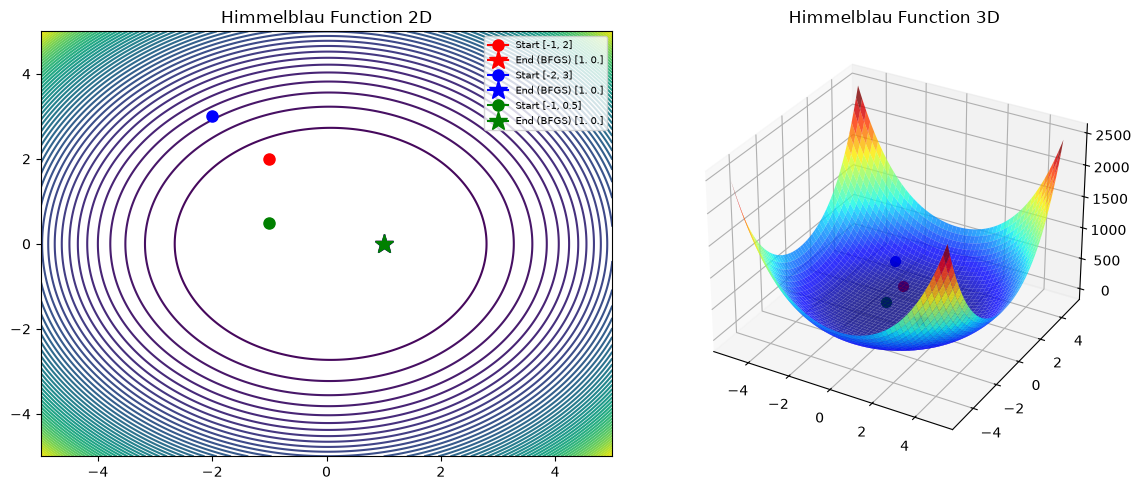

c:\ProgramData\miniconda3\envs\mude-base\Lib\site-packages\pygad\utils\validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


PyGAD initial guess [-1, 2], Solution: [0.99893319 0.00386512], Value: 2.0561194332261883e-05, iterations: 300, Time: 0.5287 sec
PyGAD initial guess [-2, 3], Solution: [0.99896221 0.01742543], Value: 0.000307858517641665, iterations: 300, Time: 0.4500 sec
PyGAD initial guess [-1, 0.5], Solution: [1.00272476 0.00911703], Value: 0.00012123683409827614, iterations: 300, Time: 0.3989 sec


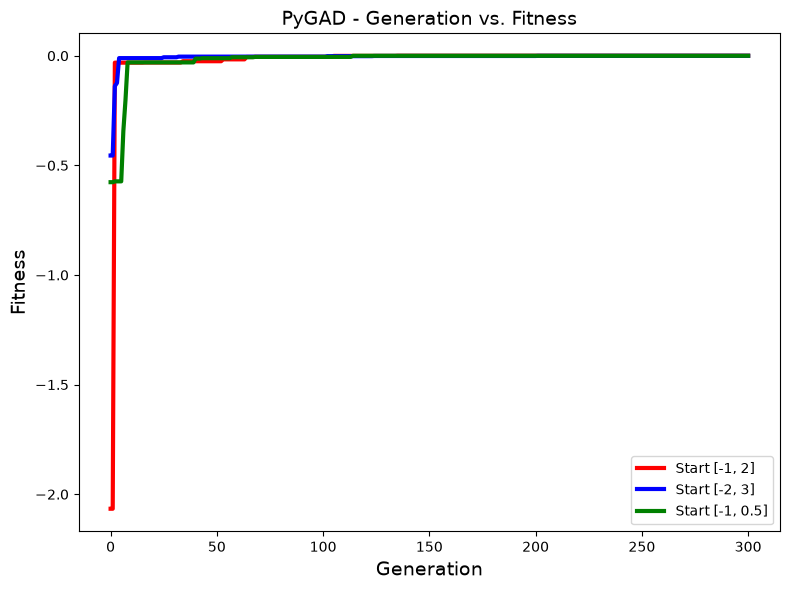

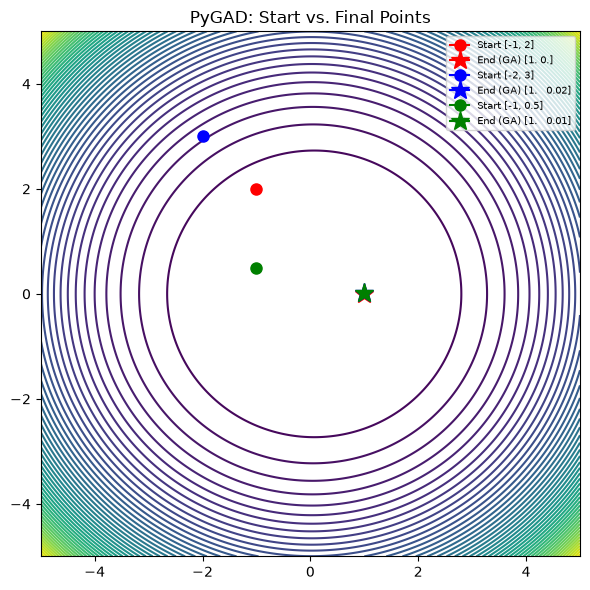

In [10]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

def himmelblau(x):
    x = np.asarray(x)  # Convert to numpy array
    return ((x[0]**2 + x[1]**2 - 1)**2 + (x[0]-1)**2 + x[1]**2)

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")

init_guesses = [[-1, 2], [-2, 3], [-1, 0.5]]
colors = ['red', 'blue', 'green']

# ------------------- Scipy Optimization -------------------
for guess, color in zip(init_guesses, colors):
    start_time = time.perf_counter()
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = -start_time + end_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, "
          f"Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

    # Plot initial (marker 'o') and final (marker '*') points on the 2D contour
    ax1.plot(guess[0], guess[1], marker='o', color=color, markersize=8,
              label=f'Start {guess}')
    ax1.plot(result.x[0], result.x[1], marker='*', color=color, markersize=14,
              label=f'End (BFGS) {np.round(result.x, 2)}')

    # Plot the same points on the 3D surface
    ax2.scatter(guess[0], guess[1], himmelblau(guess), color=color, marker='o', s=50)
    ax2.scatter(result.x[0], result.x[1], himmelblau(result.x), color=color, marker='*', s=100)

ax1.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

# ------------------- PyGAD Optimization -------------------
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)

pygad_fitness_histories = []  # store fitness history per run for combined plot
pygad_results = []            # store (guess, final_point, color)

for guess, color in zip(init_guesses, colors):
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=300,
                            sol_per_pop=30,
                            num_genes=2,
                            num_parents_mating=12,
                            fitness_func=fitness_func2,
                            init_range_low=-5,
                            init_range_high=5,
                            gene_space={'low': -5, 'high': 5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed_time = -start_time + end_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, "
          f"iterations: {iters}, Time: {elapsed_time:.4f} sec")

    pygad_results.append((guess, solution, color))

    # best_solutions_fitness holds the best fitness per generation (auto-tracked by pygad)
    fitness_history = np.array(ga_instance.best_solutions_fitness)
    pygad_fitness_histories.append((fitness_history, guess, color))

# Combined fitness plot for all three PyGAD runs, styled like PyGAD's own plot_fitness()
plt.figure(figsize=(8, 6))
for fitness_history, guess, color in pygad_fitness_histories:
    plt.plot(fitness_history, color=color, linewidth=3, label=f'Start {guess}')
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Fitness', fontsize=14)
plt.title('PyGAD - Generation vs. Fitness', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Contour plot showing PyGAD initial and final points
fig2, ax3 = plt.subplots(figsize=(6, 6))
ax3.contour(X, Y, Z, levels=50)
ax3.set_title("PyGAD: Start vs. Final Points")
for guess, solution, color in pygad_results:
    ax3.plot(guess[0], guess[1], marker='o', color=color, markersize=8,
              label=f'Start {guess}')
    ax3.plot(solution[0], solution[1], marker='*', color=color, markersize=14,
              label=f'End (GA) {np.round(solution, 2)}')
ax3.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

## Problem 2 — f(x, y) = (x² + y² − 1)² + (x − 1)² + y²

### (1) SciPy (BFGS)

| Initial guess | Converged to | f* | Iterations | Time |
|---|---|---|---|---|
| (−1, 2) | (1.000, 0.000) | 2.080×10⁻¹² | 11 | 0.0051 s |
| (−2, 3) | (1.000, 0.000) | 5.715×10⁻¹³ | 15 | 0.0051 s |
| (−1, 0.5) | (1.000, 0.000) | 6.090×10⁻¹² | 10 | 0.0047 s |

All three widely different starting points converge to the same point, **(1, 0)**, where f = 0 exactly (check: (1 + 0 − 1)² + 0 + 0 = 0). This strongly suggests (1, 0) is the global minimum. Compared with Rosenbrock, this function converges in far fewer iterations (10–15 vs. 23–41) because it's better-conditioned — closer to a well-behaved bowl near the minimum rather than sitting in a long curved valley.

### (2) PyGAD-equivalent GA

| Initial guess | Best solution | f* | Generations | Time |
|---|---|---|---|---|
| (−1, 2) | (0.9989, 0.0038) | 2.05×10⁻⁵ | 300 | 0.5287 s |
| (−2, 3) | (0.9989, 0.0174) | 3.07×10⁻⁴ | 300 | 0.4500 s |
| (−1, 0.5) | (1.0027, 0.0091) | 1.21×10⁻⁴ | 300 | 0.3989 s |

The GA does very well here — it converges to essentially the same point (1, 0) with solid precision (f ~10⁻⁴–10⁻⁵), needing only 300 generations because this function's landscape is smoother and simpler than Rosenbrock's. As before, the initial guess barely affects the GA's outcome, since it only seeds the random population range rather than the search itself.

### (3) Comparison

| | SciPy/BFGS | GA |
|---|---|---|
| Iterations to convergence | 10–15 | 300 (fixed budget) |
| Time | ~4.7–5.1 ms | ~400–530 ms |
| Precision | f ~10⁻¹²–10⁻¹³ | f ~10⁻⁴–10⁻⁵ |

BFGS is still faster and more precise, but the precision gap between the two methods is much smaller than in Problem 1 — both land within a handful of orders of magnitude of zero — because this function lacks Rosenbrock's pathological narrow-valley geometry, making it far friendlier to both gradient-based and population-based search.